**Useful functions used later in the Notebook**

In [ ]:
def plot_hyperplane(ax, w, b, X, y, with_margin=False):
    # Scatter points
    ax.scatter(X[y==1, 0], X[y==1, 1], color="blue", label="Class +1")
    ax.scatter(X[y==-1, 0], X[y==-1, 1], color="red", label="Class -1")

    # Compute line points
    x_min, x_max = ax.get_xlim()
    x_vals = np.linspace(x_min, x_max, 100)
    # Equation: w1*x + w2*y + b = 0 → y = -(w1*x + b)/w2
    y_vals = -(w[0]*x_vals + b)/w[1]
    ax.plot(x_vals, y_vals, "k-", linewidth=2)

    if with_margin:
        # Margin lines: w.x+b = ±1 → y = -(w1*x+b±1)/w2
        y_vals_plus = -(w[0]*x_vals + b - 1)/w[1]
        y_vals_minus = -(w[0]*x_vals + b + 1)/w[1]
        ax.plot(x_vals, y_vals_plus, "g--", linewidth=1.5)
        ax.plot(x_vals, y_vals_minus, "g--", linewidth=1.5)

    ax.set_title(f"w={w}, b={b}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

In [ ]:
# Plot decision boundary
def plot_svm(clf, X, y):
    plt.figure(figsize=(6,6))
    # Plot data
    plt.scatter(X[y==1, 0], X[y==1, 1], c="blue", label="Class +1")
    plt.scatter(X[y==-1, 0], X[y==-1, 1], c="red", label="Class -1")

    # Decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 200),
                         np.linspace(ylim[0], ylim[1], 200))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot margins and boundary
    plt.contour(xx, yy, Z, colors='k',
                levels=[-1, 0, 1], alpha=0.7,
                linestyles=['--', '-', '--'])

    # Highlight support vectors
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
                s=150, facecolors='none', edgecolors='green', linewidths=2,
                label="Support Vectors")

    plt.legend()
    plt.title("SVM Classifier")
    plt.show()

In [ ]:
def plot_svm_manual(X, y, w, b):
    plt.figure(figsize=(6,6))
    plt.scatter(X[y==1,0], X[y==1,1], c='blue')
    plt.scatter(X[y==-1,0], X[y==-1,1], c='red')

    # Decision boundary
    xx = np.linspace(-6, 7, 200)   # adjust x range
    yy = -(w[0].value*xx + b.value)/w[1].value
    plt.plot(xx, yy, "k-")

    # Margins
    yy_plus = -(w[0].value*xx + b.value - 1)/w[1].value
    yy_minus = -(w[0].value*xx + b.value + 1)/w[1].value
    plt.plot(xx, yy_plus, "g--")
    plt.plot(xx, yy_minus, "g--")

    # Set same range as sklearn plot
    plt.xlim(-6, 7)
    plt.ylim(0, 12)

    plt.legend()
    plt.title("Hard-Margin SVM (solved with optimization)")
    plt.show()

<h1><b>Support Vector Machines (SVM)</b></h1>

<h2><b>1. Hard-margin Classifier :</b></h2>

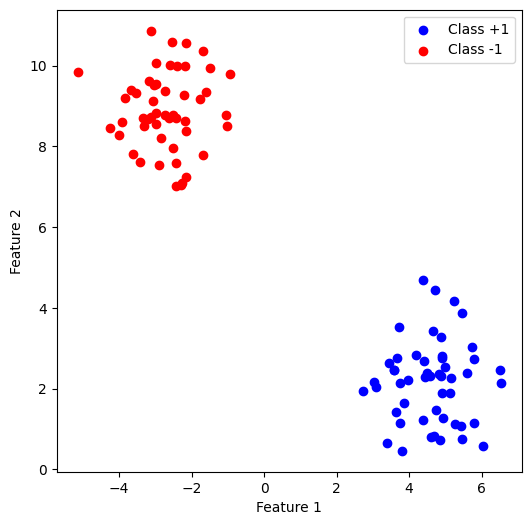

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Create blobs (2 clusters)
X, y = make_blobs(
    n_samples=100,        # number of points
    centers=2,            # two clusters
    n_features=2,         # 2D
    cluster_std=1.0,      # spread of clusters
    random_state=42
)

# labels
y = np.where(y == 0, -1, 1)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Class +1')
plt.scatter(X[y==-1, 0], X[y==-1, 1], color='red', label='Class -1')
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


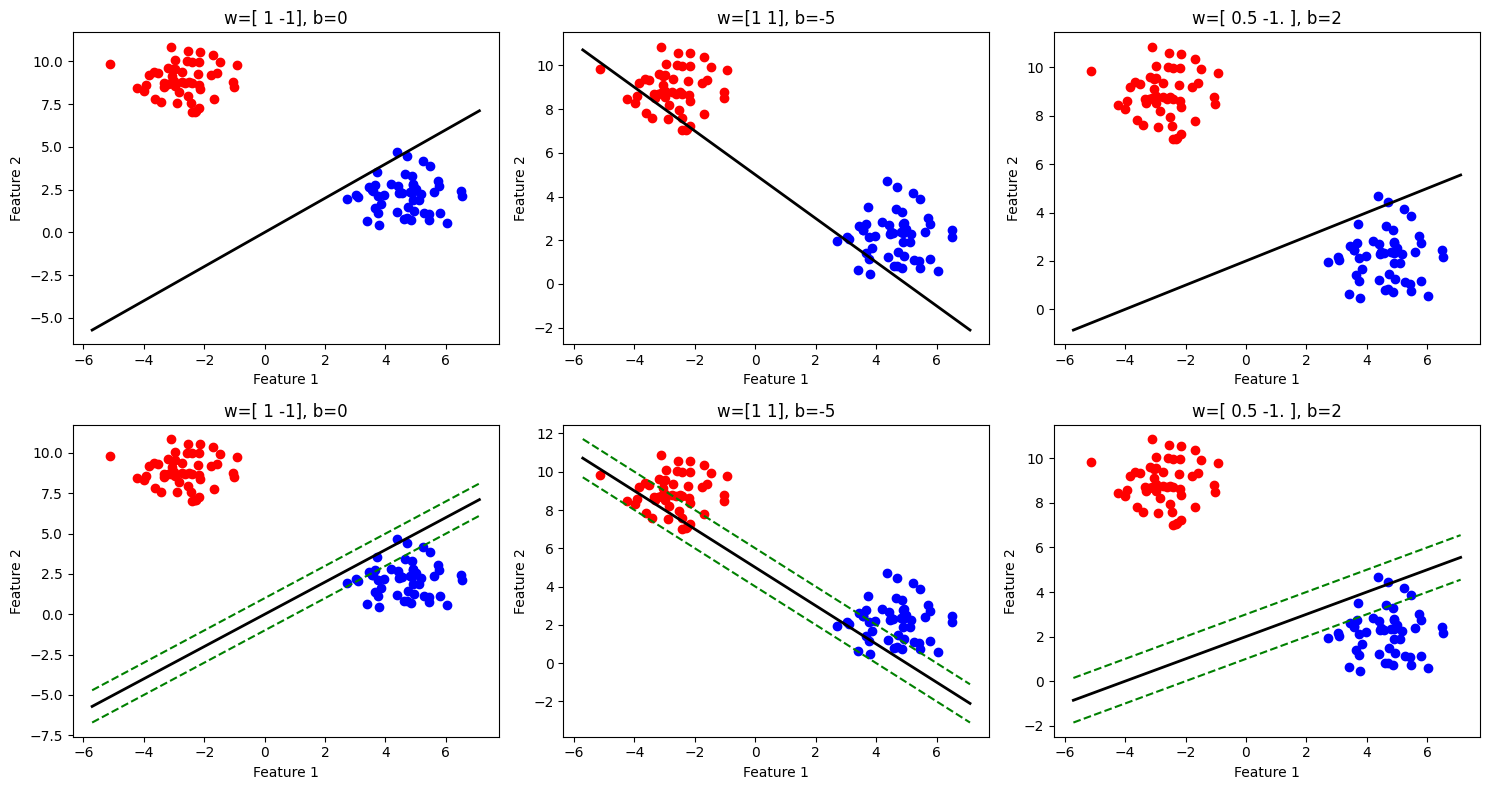

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 3 hyperplanes
random_planes = [
    (np.array([1, -1]), 0),
    (np.array([1, 1]), -5),
    (np.array([0.5, -1]), 2)
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (w, b) in enumerate(random_planes):
    plot_hyperplane(axes[0, i], w, b, X, y, with_margin=False)
    plot_hyperplane(axes[1, i], w, b, X, y, with_margin=True)

plt.tight_layout()
plt.show()


w: [ 0.24748994 -0.17407192]
b: 0.7341550476191021


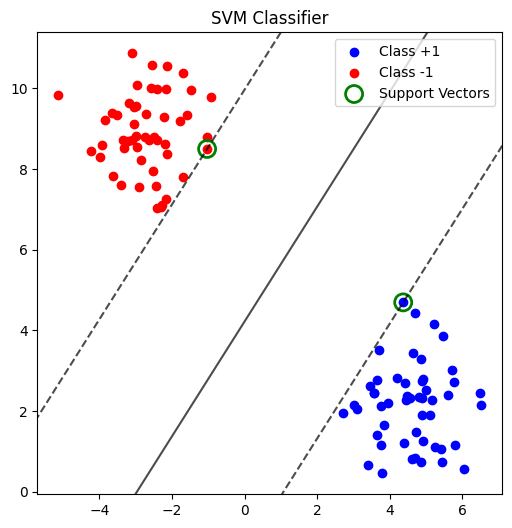

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Training
svm_clf = SVC(kernel="linear", C=1)
svm_clf.fit(X, y)

w = svm_clf.coef_[0]
b = svm_clf.intercept_[0]
print("w:", w)
print("b:", b)

plot_svm(svm_clf, X, y)

<h2><b>Doing it a little 'manual' way !</b></h2>

Optimal w: [ 0.24749024 -0.17407149]
Optimal b: 0.7341517309759628


/tmp/ipython-input-2845705518.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


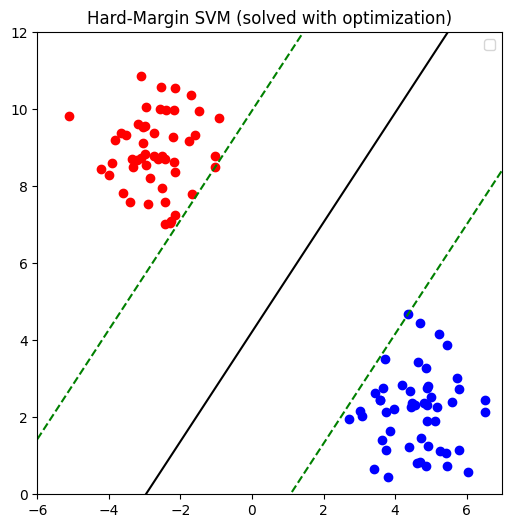

In [ ]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt


w = cp.Variable(X.shape[1])   # weight
b = cp.Variable()             # bias

# Objective:     minimize 1/2 ||w||^2
# Constraints:   y_i (w^T x_i + b) >= 1

objective = cp.Minimize(0.5 * cp.norm(w, 2)**2)
constraints = [y[i] * (X[i] @ w + b) >= 1 for i in range(len(y))]

# Problem
problem = cp.Problem(objective, constraints)
problem.solve()

print("Optimal w:", w.value)
print("Optimal b:", b.value)

plot_svm_manual(X, y, w, b)


<h3><b>Multi-class Linear Classification</b></h3>

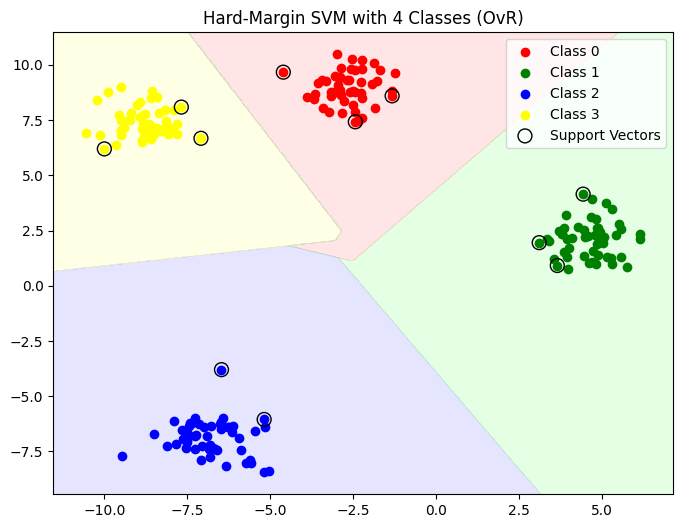

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

# Generate 4 clusters (linearly separable)
X, y = make_blobs(n_samples=200, centers=4, cluster_std=0.8, random_state=42)

# Train
svm_clf = SVC(kernel="linear", C=1e10, decision_function_shape='ovr')
svm_clf.fit(X, y)

# Plot
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = svm_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Define colors
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA'])
cmap_bold = ['red', 'green', 'blue', 'yellow']

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

# Data points
for i, color in zip(range(4), cmap_bold):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=color, label=f"Class {i}")

# Support vectors
plt.scatter(svm_clf.support_vectors_[:, 0],
            svm_clf.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='k', label="Support Vectors")

plt.title("Hard-Margin SVM with 4 Classes (OvR)")
plt.legend()
plt.show()

<h2><b>2. Soft-margin Classifier</b></h2>

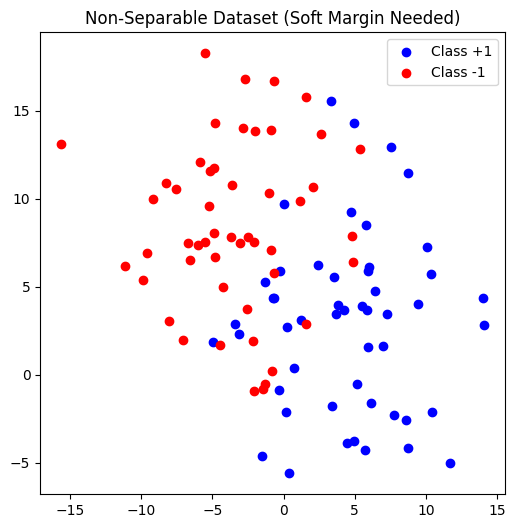

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Non-separable dataset (more overlap)
X, y = make_blobs(n_samples=100, centers=2, n_features=2, cluster_std=5.0, random_state=42)
y = np.where(y==0, -1, 1)  # labels {-1, +1}

# Plot
plt.figure(figsize=(6,6))
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label="Class +1")
plt.scatter(X[y==-1, 0], X[y==-1, 1], color='red', label="Class -1")
plt.legend()
plt.title("Non-Separable Dataset (Soft Margin Needed)")
plt.show()

w: [ 0.23058605 -0.12925584]
b: 0.683130324471619


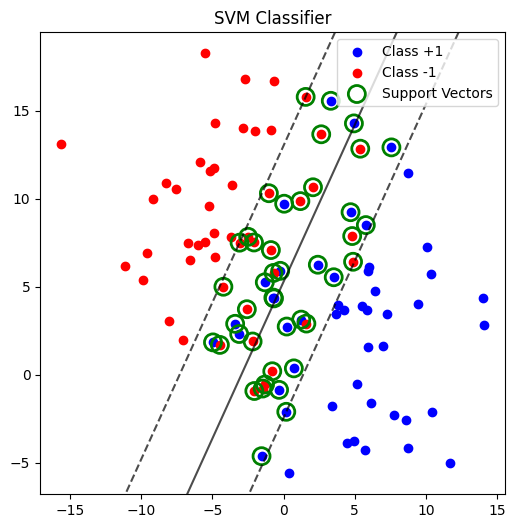

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Training
svm_clf = SVC(kernel="linear", C=0.01)
svm_clf.fit(X, y)

w = svm_clf.coef_[0]
b = svm_clf.intercept_[0]
print("w:", w)
print("b:", b)

plot_svm(svm_clf, X, y)

<h2><b>3. Non-linear Classification</b></h2>

<h3><b>Gaussian Kernels</b></h3>

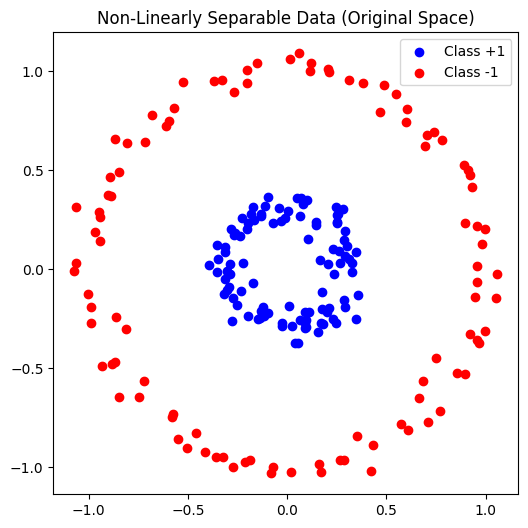

In [ ]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=200, factor=0.3, noise=0.05, random_state=42)
y = np.where(y==0, -1, 1)  # {-1, +1} labels

# Plot original space
plt.figure(figsize=(6,6))
plt.scatter(X[y==1, 0], X[y==1, 1], color="blue", label="Class +1")
plt.scatter(X[y==-1, 0], X[y==-1, 1], color="red", label="Class -1")
plt.legend()
plt.title("Non-Linearly Separable Data (Original Space)")
plt.show()

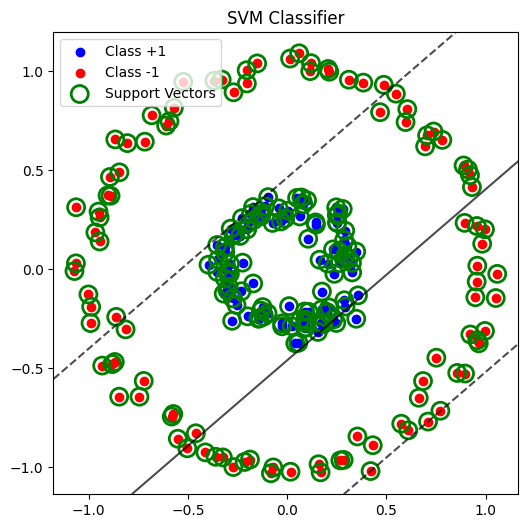

In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(kernel="linear", C=1000)
svm_clf.fit(X, y)

plot_svm(svm_clf, X, y)

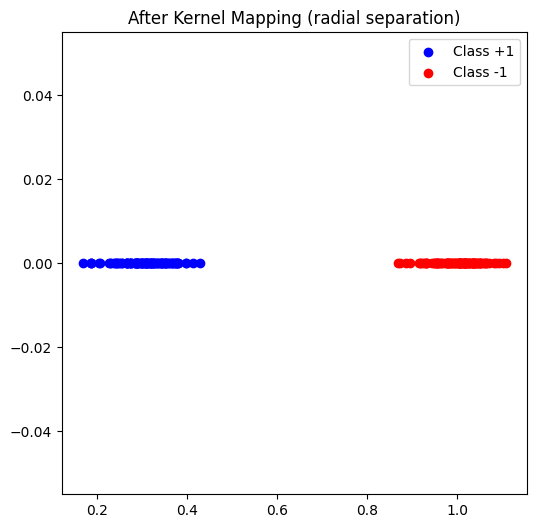

In [ ]:
r = np.sqrt(X[:,0]**2 + X[:,1]**2)

plt.figure(figsize=(6,6))
plt.scatter(r[y==1], np.zeros_like(r[y==1]), color="blue", label="Class +1")
plt.scatter(r[y==-1], np.zeros_like(r[y==-1]), color="red", label="Class -1")
plt.title("After Kernel Mapping (radial separation)")
plt.legend()
plt.show()

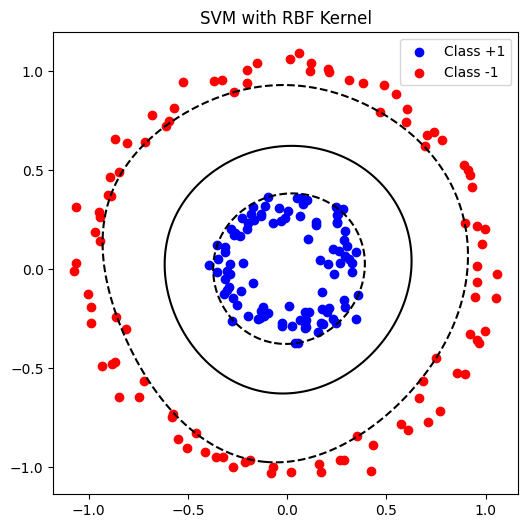

In [ ]:
from sklearn.svm import SVC

# Train RBF kernel SVM
svm_clf = SVC(kernel="rbf", gamma=2)
svm_clf.fit(X, y)

# Plot decision boundary
def plot_svm_kernel(clf, X, y, title):
    plt.figure(figsize=(6,6))
    plt.scatter(X[y==1, 0], X[y==1, 1], c="blue", label="Class +1")
    plt.scatter(X[y==-1, 0], X[y==-1, 1], c="red", label="Class -1")

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 300),
                         np.linspace(ylim[0], ylim[1], 300))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contour(xx, yy, Z, levels=[-1,0,1], colors="k", linestyles=["--","-","--"])
    plt.legend()
    plt.title(title)
    plt.show()

plot_svm_kernel(svm_clf, X, y, "SVM with RBF Kernel")